## Similarity vs. Globality Anaysis
Here we analyze the dependance of the similarity metric on globality 

In [16]:
import os
# change to platonic-rep root directory
os.chdir(r'c:\Users\user\OneDrive - Technion\Documents\GitHub\platonic-rep')

In [44]:
import numpy as np  
import matplotlib.pyplot as plt
import utils 
from tasks import get_models

import pandas as pd
import seaborn as sns

sim_params = {
    'modelset': 'mini',
    'dataset': 'minhuh\\prh',
    'subset': 'wit_1024',
    'modality_x': 'vision',
    'modality_y': 'vision',
    'pool_x': 'cls',
    'pool_y': 'cls',
    'prompt_x': False,
    'prompt_y': False,
    'metric': 'cknna',
    'topk_len': 10,
}
fontsize = 16
results_dir = os.path.join('results', 'alignment')
load_path = utils.to_alignment_filename(
            results_dir, sim_params['dataset'], sim_params['modelset'],
            sim_params['modality_x'], sim_params['pool_x'], sim_params['prompt_x'],
            sim_params['modality_y'], sim_params['pool_y'], sim_params['prompt_y'],
            sim_params['metric'], sim_params['topk_len']
    )
data = np.load(load_path, allow_pickle=True).item()

In [45]:
n_models = data['scores'].shape[0]
topk_vec = [5, 38, 71, 103, 136, 169, 202, 234, 267, 300]
llm_models, lvm_models = get_models(sim_params['modelset'], modality='all')
model_names = llm_models if sim_params['modality_x'] == "language" else lvm_models

In [46]:
model_names

['vit_small_patch14_dinov2.lvd142m',
 'vit_base_patch14_dinov2.lvd142m',
 'vit_base_patch16_clip_224.laion2b',
 'vit_large_patch14_clip_224.laion2b']

In [47]:
model_names_map = {
    'vit_small_patch14_dinov2.lvd142m': 'DINOv2-small',
    'vit_base_patch14_dinov2.lvd142m': 'DINOv2-base',
    'vit_base_patch16_clip_224.laion2b': 'CLIP-base',
    'vit_large_patch14_clip_224.laion2b': 'CLIP-large'
}

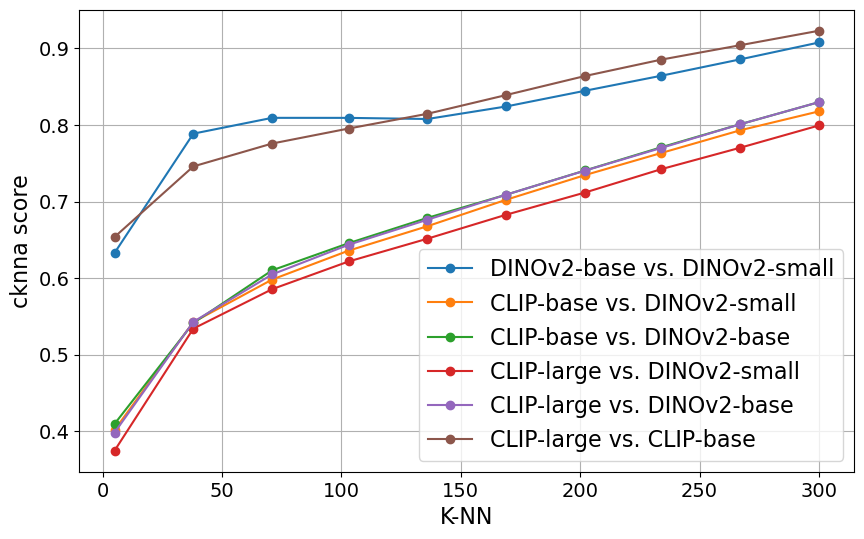

In [48]:
# plot alignment vs. topk values for models in model list
model_list = ['vit_small_patch14_dinov2.lvd142m', 
              'vit_base_patch14_dinov2.lvd142m', 
              'vit_base_patch16_clip_224.laion2b',
              'vit_large_patch14_clip_224.laion2b']

plt.figure(figsize=(10,6))
for i, model_x in enumerate(model_list):
    model_x_idx = model_names.index(model_x)
    for j, model_y in enumerate(model_list):
        model_y_idx = model_names.index(model_y)
        if i <= j:
            continue
        alignment_scores = data['scores'][model_x_idx, model_y_idx, :]
        label = f"{model_names_map.get(model_x, model_x)} vs. {model_names_map.get(model_y, model_y)}"
        plt.plot(topk_vec, alignment_scores, marker='o', label=label)

plt.xlabel('K-NN', fontsize=fontsize)
plt.ylabel(f'{sim_params["metric"]} score', fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.grid(True)
plt.legend(fontsize=fontsize)
plt.savefig(f'post_processing/sim_globality_{sim_params["metric"]}.png', dpi=300)